# Notebook 05 — Détection d'anomalies par Isolation Forest

**Objectif**: Remplacer les règles heuristiques (z-score, heure) par un détecteur  
d'anomalies non-supervisé basé sur l'algorithme Isolation Forest.

**Données**: transactions Debit uniquement (les crédits ne sont pas des anomalies de dépense)  
**Features**: amount, hour, is_weekend, category_encoded  
**Output**: `backend/models_store/isolation_forest.pkl` + `anomaly_label_encoder.pkl`

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
import joblib

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

PROJECT_ROOT  = Path.cwd().parent
DATA_DIR      = PROJECT_ROOT / 'data' / 'processed'
MODELS_STORE  = PROJECT_ROOT / 'backend' / 'models_store'
MODELS_STORE.mkdir(parents=True, exist_ok=True)

print('Project root :', PROJECT_ROOT)
print('Models store :', MODELS_STORE)

Project root : c:\Users\oumai\Downloads\PE\PE
Models store : c:\Users\oumai\Downloads\PE\PE\backend\models_store


## 1. Chargement des données

In [2]:
df = pd.read_csv(DATA_DIR / 'transactions_segmentees.csv', low_memory=False)
df = df.dropna(subset=['category', 'amount', 'direction']).copy()
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['amount'] = pd.to_numeric(df['amount'], errors='coerce').abs()
df = df.dropna(subset=['amount'])

print(f'Total transactions: {len(df):,}')
print(f'Colonnes disponibles: {list(df.columns)}')

Total transactions: 46,702
Colonnes disponibles: ['transaction_id', 'customer_id', 'transaction_date', 'transaction_time', 'account_type', 'payment_method', 'direction', 'amount', 'balance_after', 'narration', 'merchant_name', 'merchant_city', 'merchant_country', 'transaction_datetime', 'year', 'month', 'day', 'hour', 'weekday', 'month_name', 'clean_narration', 'clean_merchant_name', 'is_debit', 'is_credit', 'transaction_type', 'time_period', 'text_to_segment', 'category']


## 2. Ingénierie des features

In [3]:
# hour: utilise la colonne déjà calculée dans le CSV si disponible
if 'hour' in df.columns:
    df['hour'] = pd.to_numeric(df['hour'], errors='coerce').fillna(12).astype(int)
    print('Colonne hour trouvée dans le CSV.')
elif 'transaction_time' in df.columns:
    df['hour'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S', errors='coerce').dt.hour
    df['hour'] = df['hour'].fillna(
        pd.to_datetime(df['transaction_time'], format='%H:%M', errors='coerce').dt.hour
    ).fillna(12).astype(int)
    print('Heure extraite de transaction_time.')
else:
    df['hour'] = 12
    print('Heure non disponible — valeur par défaut 12.')

# is_weekend
df['day_of_week'] = df['transaction_date'].dt.dayofweek
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)

print(f'\nDistribution des heures (sample):')
print(df['hour'].value_counts().sort_index().head(10))

Colonne hour trouvée dans le CSV.

Distribution des heures (sample):
hour
0       67
1       55
2       68
3       45
4       48
7     2639
8     2820
9     2898
10    2884
11    2992
Name: count, dtype: int64


In [4]:
# Filtrer uniquement les débits
debits = df[df['direction'] == 'Debit'].copy()
print(f'Transactions Debit: {len(debits):,} sur {len(df):,} ({len(debits)/len(df)*100:.1f}%)')
print(f'\nDistribution montants Debit:')
print(debits['amount'].describe())

Transactions Debit: 45,607 sur 46,702 (97.7%)

Distribution montants Debit:
count    45607.000000
mean       218.334641
std        272.098278
min          2.570000
25%         45.895000
50%        124.790000
75%        263.045000
max       2118.750000
Name: amount, dtype: float64


In [5]:
# Encoder les catégories
le = LabelEncoder()
debits['category_encoded'] = le.fit_transform(debits['category'])

print(f'Catégories encodées: {list(zip(le.classes_, range(len(le.classes_))))}')

FEATURES = ['amount', 'hour', 'is_weekend', 'category_encoded']
X = debits[FEATURES].values
print(f'\nMatrice X shape: {X.shape}')
print(f'Features: {FEATURES}')

Catégories encodées: [('Alimentation', 0), ('E-commerce', 1), ('Factures', 2), ('Logement', 3), ('Loisirs', 4), ('Retrait cash', 5), ('Revenu', 6), ('Santé', 7), ('Shopping', 8), ('Transport', 9), ('Voyage', 10)]

Matrice X shape: (45607, 4)
Features: ['amount', 'hour', 'is_weekend', 'category_encoded']


## 3. Entraînement Isolation Forest

**Isolation Forest** isole les anomalies en construisant des arbres aléatoires.  
Les points rares (anomalies) sont isolés en moins de splits.  
`contamination=0.05` → on suppose que 5% des transactions sont anormales.

In [6]:
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42,
    n_jobs=-1,
)

debits['anomaly_label'] = iso_forest.fit_predict(X)  # -1 = anomalie, 1 = normal
debits['anomaly_score'] = iso_forest.score_samples(X)  # plus négatif = plus anormal

n_anomalies = (debits['anomaly_label'] == -1).sum()
print(f'Transactions normales  : {(debits["anomaly_label"] == 1).sum():,}')
print(f'Transactions anormales : {n_anomalies:,} ({n_anomalies/len(debits)*100:.1f}%)')

Transactions normales  : 43,326
Transactions anormales : 2,281 (5.0%)


In [7]:
# Anomalies par catégorie
anomaly_by_cat = debits.groupby('category').agg(
    total=('anomaly_label', 'count'),
    anomalies=('anomaly_label', lambda x: (x == -1).sum())
).assign(rate=lambda d: d['anomalies'] / d['total'] * 100).sort_values('rate', ascending=False)

print('\nTaux d\'anomalie par catégorie:')
print(anomaly_by_cat.to_string())


Taux d'anomalie par catégorie:
              total  anomalies       rate
category                                 
Logement       3265       1315  40.275651
Voyage         1750        556  31.771429
Santé          3213        158   4.917523
E-commerce     4193         89   2.122585
Alimentation   8832         88   0.996377
Retrait cash   3763         23   0.611214
Transport      7100         34   0.478873
Shopping       3738         15   0.401284
Loisirs        3575          2   0.055944
Factures       4684          1   0.021349
Revenu         1494          0   0.000000


## 4. Visualisations

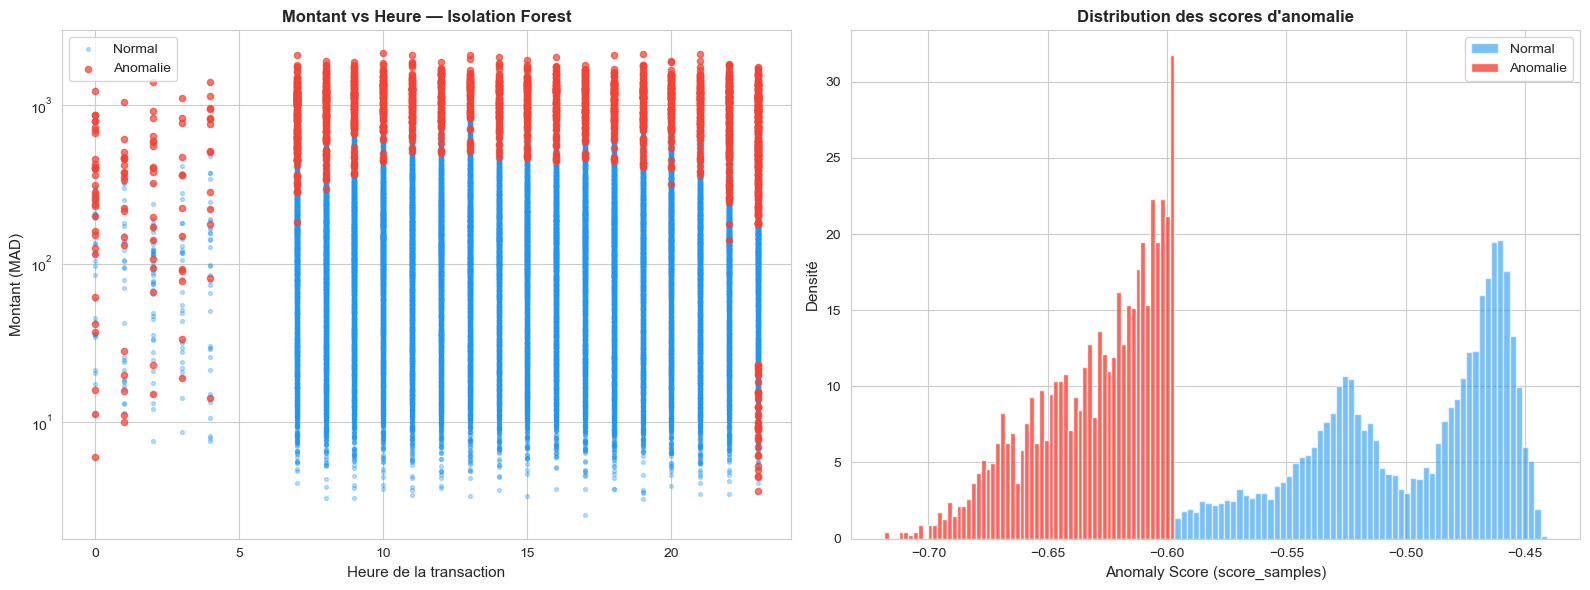

In [8]:
# Scatter plot : montant vs heure, coloré par label anomalie
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

normal  = debits[debits['anomaly_label'] ==  1]
anomaly = debits[debits['anomaly_label'] == -1]

# Plot 1: amount vs hour
ax = axes[0]
ax.scatter(normal['hour'],  normal['amount'],  c='#2196F3', alpha=0.3, s=8,  label='Normal')
ax.scatter(anomaly['hour'], anomaly['amount'], c='#F44336', alpha=0.7, s=20, label='Anomalie', zorder=3)
ax.set_xlabel('Heure de la transaction', fontsize=11)
ax.set_ylabel('Montant (MAD)', fontsize=11)
ax.set_title('Montant vs Heure — Isolation Forest', fontweight='bold')
ax.set_yscale('log')
ax.legend(fontsize=10)

# Plot 2: distribution des anomaly scores
ax2 = axes[1]
ax2.hist(normal['anomaly_score'],  bins=60, alpha=0.6, color='#2196F3', label='Normal',   density=True)
ax2.hist(anomaly['anomaly_score'], bins=60, alpha=0.8, color='#F44336', label='Anomalie', density=True)
ax2.set_xlabel('Anomaly Score (score_samples)', fontsize=11)
ax2.set_ylabel('Densité', fontsize=11)
ax2.set_title('Distribution des scores d\'anomalie', fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig(MODELS_STORE / 'isolation_forest_visualization.png', dpi=100, bbox_inches='tight')
plt.show()

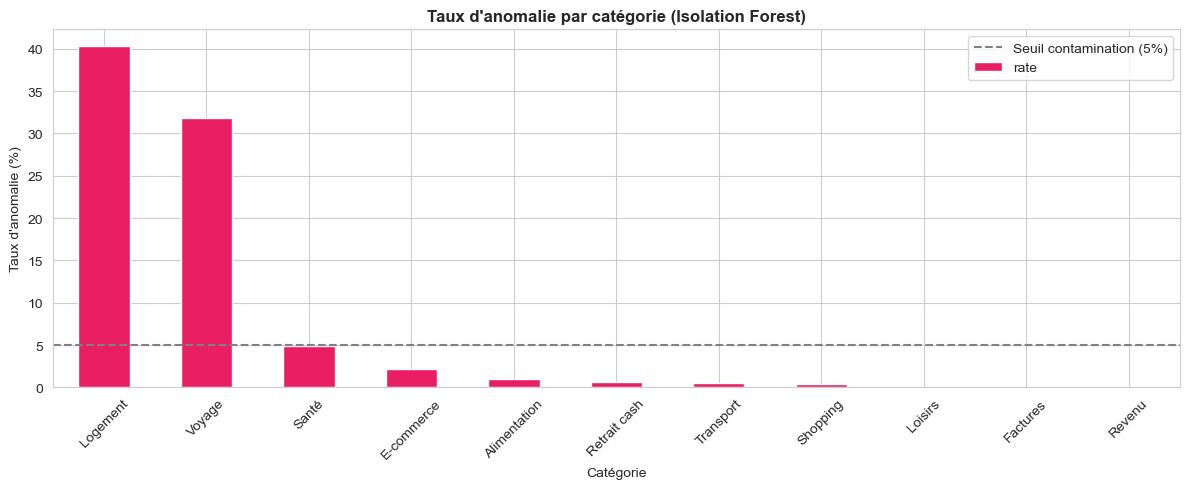

In [9]:
# Taux d'anomalie par catégorie (barplot)
fig, ax = plt.subplots(figsize=(12, 5))
anomaly_by_cat['rate'].plot(kind='bar', ax=ax, color='#E91E63', edgecolor='white')
ax.axhline(5, color='gray', linestyle='--', linewidth=1.5, label='Seuil contamination (5%)')
ax.set_xlabel('Catégorie')
ax.set_ylabel('Taux d\'anomalie (%)')
ax.set_title('Taux d\'anomalie par catégorie (Isolation Forest)', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig(MODELS_STORE / 'anomaly_rate_by_category.png', dpi=100, bbox_inches='tight')
plt.show()

In [10]:
# Top 20 transactions les plus anormales
top20 = (
    debits[debits['anomaly_label'] == -1]
    .sort_values('anomaly_score')
    .head(20)
    [['transaction_id', 'transaction_date', 'category', 'amount', 'hour', 'anomaly_score']]
    .reset_index(drop=True)
)
top20.index += 1
top20['anomaly_score'] = top20['anomaly_score'].round(4)
print('Top 20 transactions les plus anormales:')
print(top20.to_string())

Top 20 transactions les plus anormales:
   transaction_id transaction_date  category   amount  hour  anomaly_score
1       TX0027571       2024-11-23    Voyage  1283.44     7        -0.7186
2       TX0037976       2024-11-02  Logement  1400.05     2        -0.7172
3       TX0007294       2024-10-20  Logement  1609.35    23        -0.7109
4       TX0026919       2024-11-09  Logement  1588.60    23        -0.7109
5       TX0002753       2024-06-16  Logement  1548.72    23        -0.7104
6       TX0027624       2024-12-23    Voyage  1552.06    23        -0.7086
7       TX0027621       2024-12-22    Voyage  1406.81    18        -0.7079
8       TX0004076       2024-08-18    Voyage  1299.43    20        -0.7061
9       TX0032661       2024-03-23    Voyage  1194.93     8        -0.7054
10      TX0045731       2024-05-05    Voyage  1163.10    23        -0.7041
11      TX0004085       2024-08-24    Voyage  1252.08    21        -0.7037
12      TX0007339       2024-11-16  Logement  1734.12     7 

## 5. Sauvegarde des modèles

In [11]:
iso_path = MODELS_STORE / 'isolation_forest.pkl'
enc_path = MODELS_STORE / 'anomaly_label_encoder.pkl'

joblib.dump(iso_forest, iso_path)
joblib.dump(le, enc_path)

print(f'Isolation Forest sauvegardé → {iso_path}')
print(f'Label Encoder    sauvegardé → {enc_path}')

# Vérification
loaded_iso = joblib.load(iso_path)
test_X = np.array([[500, 10, 0, 0], [50000, 3, 1, 0]])
test_pred = loaded_iso.predict(test_X)
print(f'\nVérification (500 MAD / 10h vs 50000 MAD / 3h):')
for amount, pred in zip([500, 50000], test_pred):
    label = 'ANOMALIE' if pred == -1 else 'Normal'
    print(f'  {amount:,} MAD → {label}')

print(f'\n✅ Isolation Forest entraîné sur {len(debits):,} transactions Debit')
print(f'   {n_anomalies:,} anomalies détectées ({n_anomalies/len(debits)*100:.1f}%)')

Isolation Forest sauvegardé → c:\Users\oumai\Downloads\PE\PE\backend\models_store\isolation_forest.pkl
Label Encoder    sauvegardé → c:\Users\oumai\Downloads\PE\PE\backend\models_store\anomaly_label_encoder.pkl

Vérification (500 MAD / 10h vs 50000 MAD / 3h):
  500 MAD → Normal
  50,000 MAD → ANOMALIE

✅ Isolation Forest entraîné sur 45,607 transactions Debit
   2,281 anomalies détectées (5.0%)
